In [16]:
import os
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

In [18]:
DATASET_PATH = "../datasets/Chest X-Ray Images/chest_xray"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

In [19]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

In [21]:
print(train_dataset.class_to_idx)
print(val_dataset.class_to_idx)
print(test_dataset.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}


In [15]:
from torch.utils.data import WeightedRandomSampler

targets = train_dataset.targets

class_count = Counter(targets)

print(class_count)

Counter({1: 3850, 0: 1340})


In [23]:
class_weights = {}

for cls, count in class_count.items():
    class_weights[cls] = 1.0 / count

print(class_weights)

{0: 0.0007462686567164179, 1: 0.00025974025974025974}


In [24]:
sample_weights = [class_weights[label] for label in targets]

print("Total Sample Weights:", len(sample_weights))

Total Sample Weights: 5190


In [25]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("WeightedRandomSampler Created Successfully!")

WeightedRandomSampler Created Successfully!


In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [27]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


In [28]:
batch_labels = labels.numpy()

print("Batch Class Distribution:")
print(Counter(batch_labels))

Batch Class Distribution:
Counter({np.int64(1): 17, np.int64(0): 15})


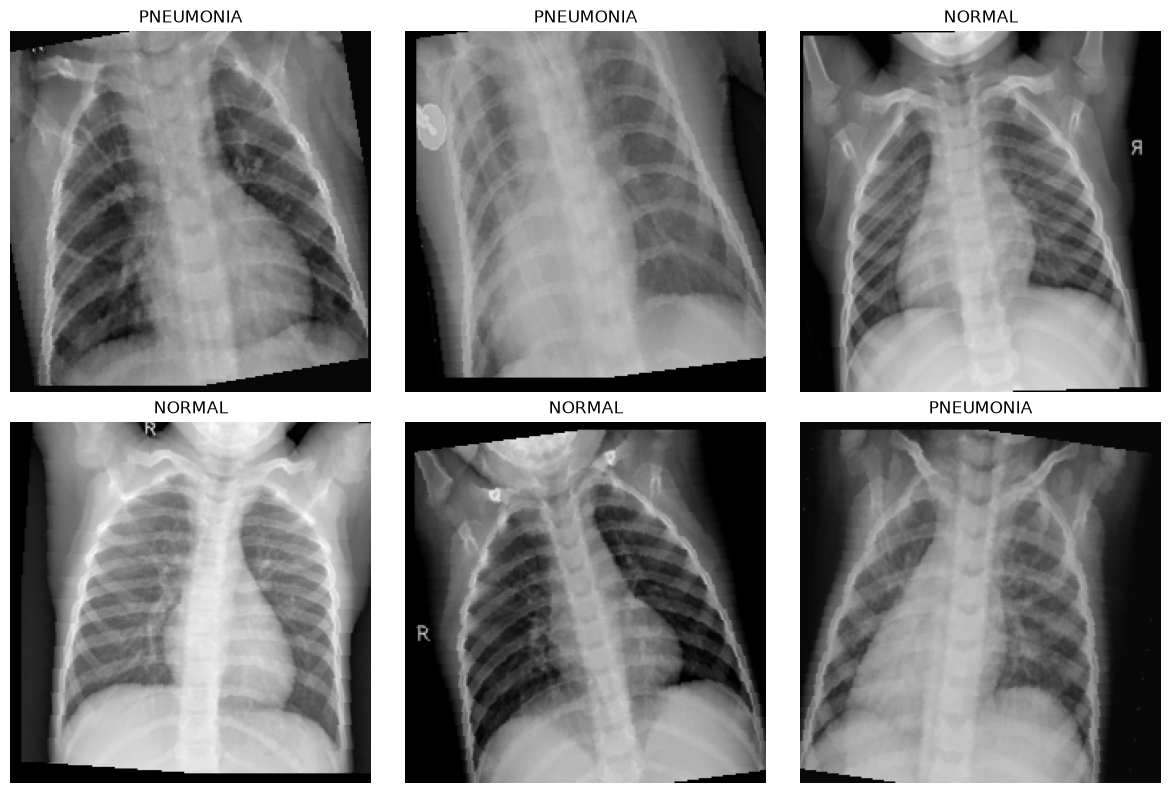

In [29]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    img = images[i].permute(1, 2, 0).numpy()

    # Reverse normalization for display
    img = img * 0.229 + 0.485
    img = img.clip(0, 1)

    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
print("=" * 60)
print("CHEST X-RAY DATA PREPROCESSING REPORT")
print("=" * 60)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Testing Images    : {len(test_dataset)}")

print(f"Batch Size        : {BATCH_SIZE}")
print(f"Image Size        : {IMAGE_SIZE} x {IMAGE_SIZE}")

print(f"Classes           : {train_dataset.classes}")
print(f"Original Distribution : {class_count}")

print("Class Imbalance Handling : WeightedRandomSampler")
print("Normalization           : Applied")
print("Data Augmentation       : Applied")

print("=" * 60)

CHEST X-RAY DATA PREPROCESSING REPORT
Training Images   : 5190
Validation Images : 16
Testing Images    : 624
Batch Size        : 32
Image Size        : 224 x 224
Classes           : ['NORMAL', 'PNEUMONIA']
Original Distribution : Counter({1: 3850, 0: 1340})
Class Imbalance Handling : WeightedRandomSampler
Normalization           : Applied
Data Augmentation       : Applied
